[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nmickevicius/MCW_BIOP_03-238_MRI/blob/main/19_parallel_imaging/parallel_imaging.ipynb)

In [ ]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 

fft = lambda inp, dim: np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
ifft = lambda inp, dim: np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
fft2 = lambda inp: fft(fft(inp,0),1)
ifft2 = lambda inp: ifft(ifft(inp,0),1)


/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_1653/1464449734.py:16: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(ksp[:,:,0])))


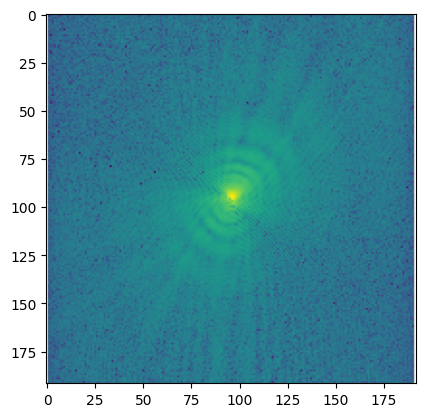

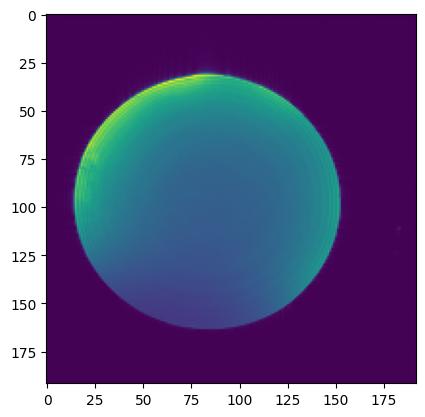

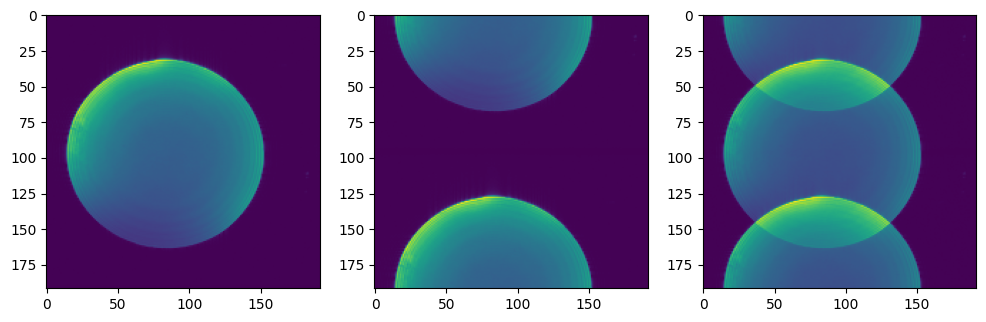

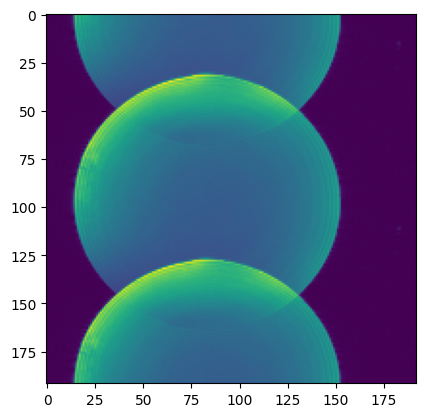

In [ ]:

# load the k-space (type in path if running locally)
# datafile = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/fbirn_32ch_kspace.h5'

# use this line if running in google colab 
!wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/fbirn_32ch_kspace.h5
datafile = os.path.join(os.getcwd(), 'fbirn_32ch_kspace.h5')
with h5py.File(datafile,'r') as F:
    ksp = F['ksp'][:] # (192, 192, 32)

ksp_2x = np.zeros_like(ksp)
ksp_2x[::2,...] = ksp[::2,...]

img = ifft2(ksp) 
rss = np.sqrt(np.sum(np.abs(img * img.conj()), axis=-1))

img_2x = ifft2(ksp_2x) 
rss_2x = np.sqrt(np.sum(np.abs(img_2x * img_2x.conj()), axis=-1))

plt.figure()
plt.imshow(np.log10(np.abs(ksp[:,:,0])))
plt.show()

plt.figure()
plt.imshow(np.abs(rss))
plt.show()

fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(np.abs(rss))
ax[1].imshow(np.roll(np.abs(rss), shift=rss.shape[0]//2, axis=0))
ax[2].imshow(np.abs(rss) + np.roll(np.abs(rss), shift=rss.shape[0]//2, axis=0))
plt.show()

plt.figure()
plt.imshow(np.abs(rss_2x))
plt.show()


# Make Coil Sensitivity Maps 

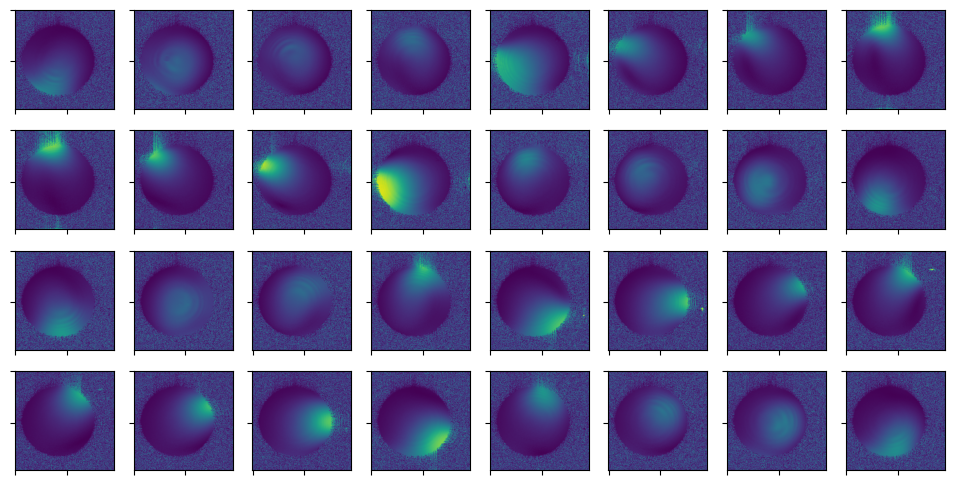

In [42]:
denom = rss 
denom[denom == 0.0] = 1.0 
S = img / denom[...,None]

fig,ax = plt.subplots(4,8, figsize=(12,6))
for r in range(4):
    for c in range(8):
        idx = r*8 + c 
        ax[r,c].imshow(np.abs(S[:,:,idx]), vmin=0.0, vmax=np.max(np.abs(S)))
        ax[r,c].set_xticklabels([])
        ax[r,c].set_yticklabels([])
plt.show()


# Simple SENSE Reconstruction (for R=2)

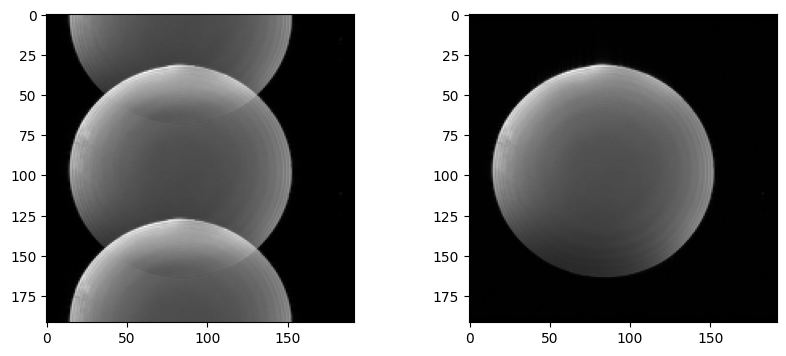

In [53]:

aliased = ifft2(ksp_2x)
rss_aliased = np.sqrt(np.sum(np.abs(aliased * aliased.conj()),axis=-1))

N = ksp_2x.shape[0]
rec_sens = np.zeros_like(ksp_2x[...,0])

for i in range(N//2):
    for c in range(N):
        Y = aliased[i,c,:] # extracting all coils
        A = np.stack([ S[i,c,:], S[i+N//2,c,:]], axis=-1)
        try:
            X = np.linalg.lstsq(A, Y, rcond=None)[0]
            rec_sens[i,c] = X[0]
            rec_sens[i+N//2,c] = X[1]
        except:
            pass 


fig,ax = plt.subplots(1,2,figsize=(10,4))
ax[0].imshow(np.abs(rss_aliased), cmap='gray')
ax[1].imshow(np.abs(rec_sens), cmap='gray')
plt.show()


# SENSE Reconstruction for R=3

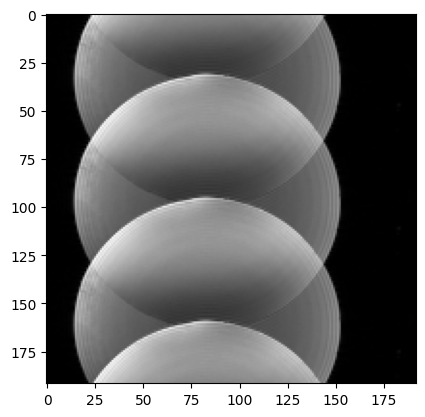

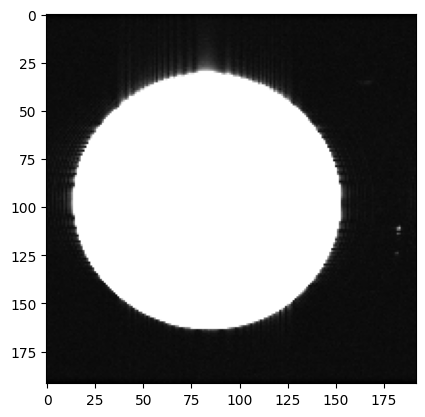

In [50]:


ksp_3x = np.zeros_like(ksp) 
ksp_3x[::3, ...] = ksp[::3, ...]

aliased = ifft2(ksp_3x) 
rss_aliased = np.sqrt(np.sum(np.abs(aliased * aliased.conj()), axis=-1))
plt.figure()
plt.imshow(rss_aliased, cmap='gray')
plt.show()

rec_sens = np.zeros_like(ksp[:,:,0])

for i in range(N//3):
    for c in range(N):

        Y = aliased[i,c,:]
        A = np.stack([ S[i,c,:], S[i+N//3,c,:], S[i+2*N//3,c,:] ], axis=-1)
        X = np.linalg.lstsq(A, Y, rcond=None)[0]
        rec_sens[i,c] = X[0]
        rec_sens[i+N//3,c] = X[1] 
        rec_sens[i+2*N//3,c] = X[2]

plt.figure()
plt.imshow(np.abs(rec_sens), cmap='gray', vmax=0.1*np.max(np.abs(rec_sens)))
plt.show()
    

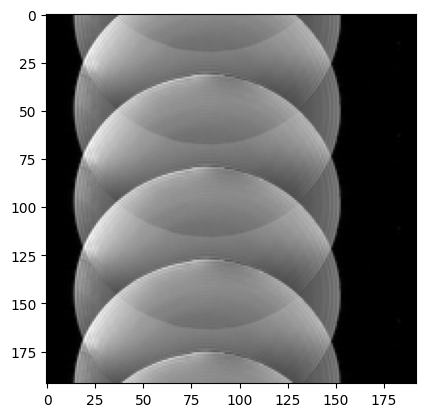

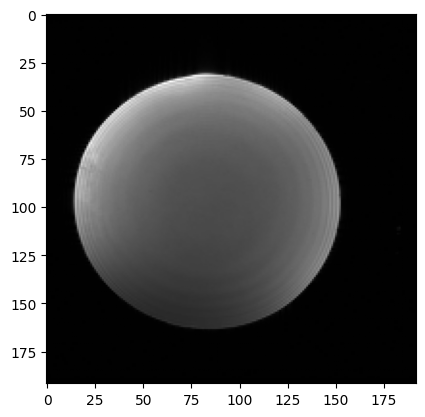

In [51]:


ksp_4x = np.zeros_like(ksp) 
ksp_4x[::4, ...] = ksp[::4, ...]

aliased = ifft2(ksp_4x) 
rss_aliased = np.sqrt(np.sum(np.abs(aliased * aliased.conj()), axis=-1))
plt.figure()
plt.imshow(rss_aliased, cmap='gray')
plt.show()

rec_sens = np.zeros_like(ksp[:,:,0])

for i in range(N//4):
    for c in range(N):

        Y = aliased[i,c,:]
        A = np.stack([ S[i,c,:], S[i+N//4,c,:], S[i+2*N//4,c,:], S[i+3*N//4,c,:] ], axis=-1)
        X = np.linalg.lstsq(A, Y, rcond=None)[0]
        rec_sens[i,c] = X[0]
        rec_sens[i+N//4,c] = X[1] 
        rec_sens[i+2*N//4,c] = X[2]
        rec_sens[i+3*N//4,c] = X[3]

plt.figure()
plt.imshow(np.abs(rec_sens), cmap='gray')
plt.show()
    

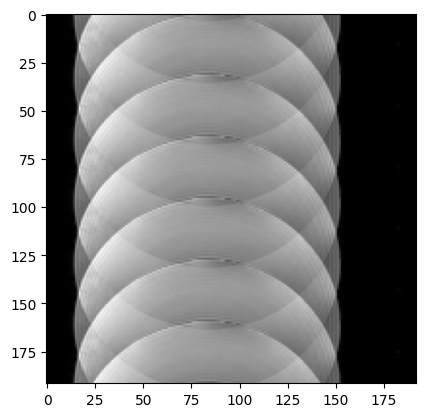

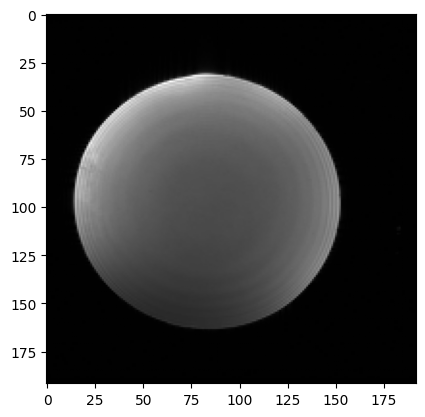

In [54]:


ksp_6x = np.zeros_like(ksp) 
ksp_6x[::6, ...] = ksp[::6, ...]

aliased = ifft2(ksp_6x) 
rss_aliased = np.sqrt(np.sum(np.abs(aliased * aliased.conj()), axis=-1))
plt.figure()
plt.imshow(rss_aliased, cmap='gray')
plt.show()

rec_sens_6x = np.zeros_like(ksp[:,:,0])

for i in range(N//6):
    for c in range(N):

        Y = aliased[i,c,:]
        A = np.stack([ S[i,c,:], S[i+N//6,c,:], S[i+2*N//6,c,:], S[i+3*N//6,c,:], S[i+4*N//6,c,:], S[i+5*N//6,c,:] ], axis=-1)
        X = np.linalg.lstsq(A, Y, rcond=None)[0]
        rec_sens_6x[i,c] = X[0]
        rec_sens_6x[i+N//6,c] = X[1] 
        rec_sens_6x[i+2*N//6,c] = X[2]
        rec_sens_6x[i+3*N//6,c] = X[3]
        rec_sens_6x[i+4*N//6,c] = X[4]
        rec_sens_6x[i+5*N//6,c] = X[5]

plt.figure()
plt.imshow(np.abs(rec_sens_6x), cmap='gray')
plt.show()
    

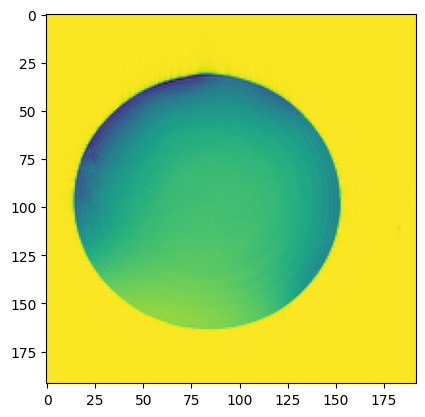

In [55]:
plt.figure()
plt.imshow(np.abs(rec_sens_6x) - np.abs(rec_sens))
plt.show()

In [59]:
!pip3 install tqdm
from tqdm import tqdm 

ncalib = 24 

i1 = int(N/2 - ncalib/2)
i2 = i1 + ncalib 
calibration_data = ksp[i1:i2,...]

# calculate the interpolation weights (2*3*Nc)
w = []

# loop over all the target coils
for tcoil in tqdm(range(32)):

    A = [] # a matrix with source points 
    Y = [] # a vector with target points 

    # i loops over the number of times that the patch of nearby points
    # fits in the number of rows (phase encoding lines) in the calibration data 
    for i in range(1, ncalib-1):

        # j loops over the number of times that the patch of nearby points
        # fits in the number of columns (frequency encoding points) in the calibration data
        for j in range(1, N-1):

            # get the target calibration point 
            Y.append(calibration_data[i,j,tcoil])

            # build one row of matrix A
            A_row = np.zeros((2*3*32,), dtype=calibration_data.dtype)

            # loop over the source coils (which is just all of the coils, used to interpolate the target coil data)
            idx = 0
            for scoil in range(32): 
                for pe_shift in [-1, 1]:
                    for fe_shift in [-1, 0, 1]:
                        A_row[idx] = calibration_data[i+pe_shift, j+fe_shift, scoil]
                        idx += 1

            A.append(A_row)

    A = np.stack(A, axis=0)
    Y = np.array(Y, dtype=calibration_data.dtype)
    X = np.linalg.lstsq(A, Y, rcond=None)[0]
    w.append( X )


  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
You should consider upgrading via the '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/venv/bin/python3 -m pip install --upgrade pip' command.


100%|██████████| 32/32 [00:08<00:00,  3.66it/s]


In [64]:


from copy import deepcopy 
ksp_grappa = deepcopy(ksp_2x)

# loop over all the lines of ksp_2x that currently filled with zeros (because we skipped them with R=2)
for I in tqdm(range(1, ksp_2x.shape[0]-1, 2)):

    # loop over all frequency encoding points 
    for J in range(1, ksp_2x.shape[1]-1):

        # loop over target coils 
        for tcoil in range(32):

            # get the weights for current target coil 
            weights = w[tcoil]

            # loop over source coils 
            A_row = np.zeros((1, 2*3*32,), dtype=calibration_data.dtype)
            idx = 0
            for scoil in range(32): 
                for pe_shift in [-1, 1]:
                    for fe_shift in [-1, 0, 1]:
                        A_row[0,idx] = ksp_2x[I+pe_shift, J+fe_shift, scoil]
                        idx += 1

            ksp_grappa[I,J,tcoil] = A_row @ weights 
        



  0%|          | 0/95 [00:00<?, ?it/s]/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_1653/940693927.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ksp_grappa[I,J,tcoil] = A_row @ weights
100%|██████████| 95/95 [00:29<00:00,  3.25it/s]


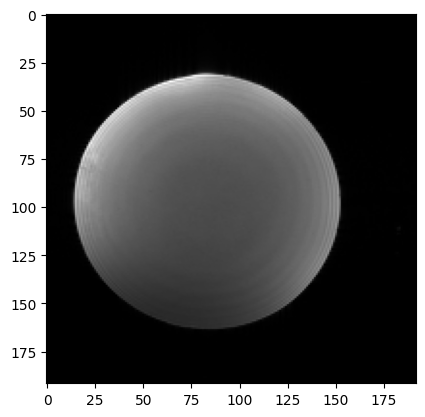

In [65]:
img_grappa = ifft2(ksp_grappa)
rss_grappa = np.sqrt(np.sum(np.abs(img_grappa * img_grappa.conj()), axis=-1))

plt.figure()
plt.imshow(rss_grappa, cmap='gray') 
plt.show()